# 03: EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", palette="muted")
plt.rcParams['figure.autolayout'] = True

listings = pd.read_pickle('../listings_cleaned.pkl')
past_rates = pd.read_pickle('../past_rates_cleaned.pkl')

for col in ['ttm_revenue', 'ttm_occupancy', 'guests', 'bedrooms', 'amenity_count']:
    listings[col] = pd.to_numeric(listings[col], errors='coerce')

print("Clean Data Loaded")

## 0. Basic Data Exploration

In [ ]:
listings.head()

In [ ]:
listings.info()

In [ ]:
listings.describe()

In [ ]:
listings.isnull().sum()

In [ ]:
past_rates.head()

In [ ]:
past_rates.info()

In [ ]:
past_rates.describe()

## 1. Univariate Analysis

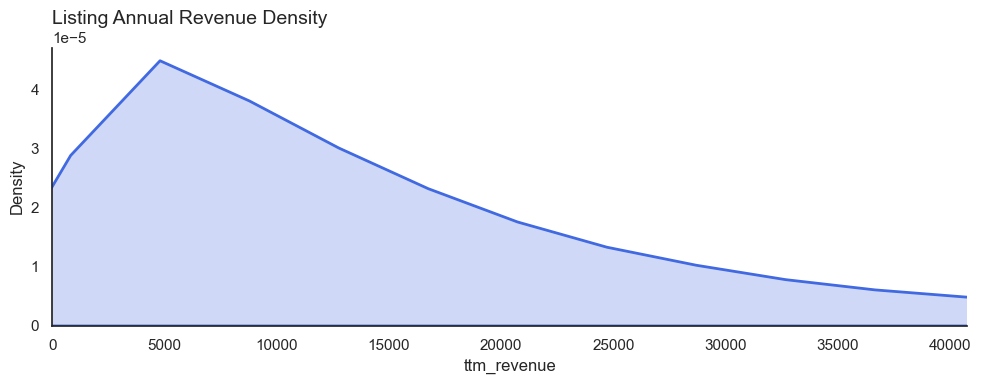

In [2]:
plt.figure(figsize=(10, 4))
sns.kdeplot(data=listings, x='ttm_revenue', fill=True, color='royalblue', lw=2)
plt.title('Listing Annual Revenue Density', fontsize=14, loc='left')
plt.xlim(0, listings['ttm_revenue'].quantile(0.9))
sns.despine()
plt.show()

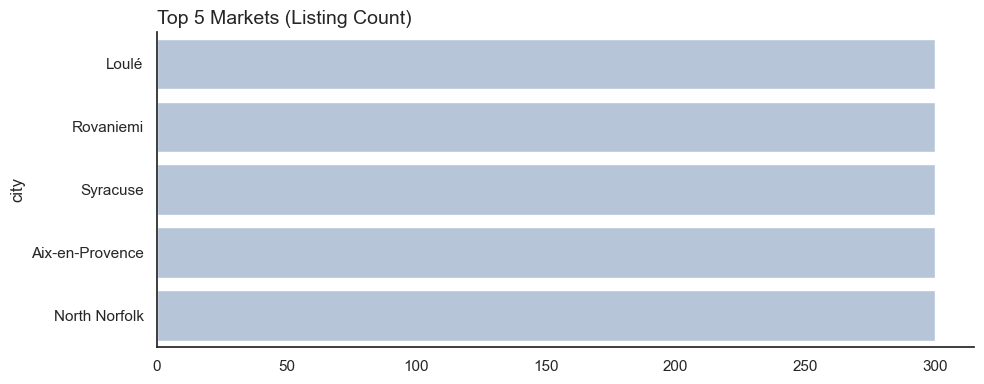

In [3]:
plt.figure(figsize=(10, 4))
top_cities = listings['city'].value_counts().head(5)
sns.barplot(x=top_cities.values, y=top_cities.index, color='lightsteelblue')
plt.title('Top 5 Markets (Listing Count)', fontsize=14, loc='left')
sns.despine()
plt.show()

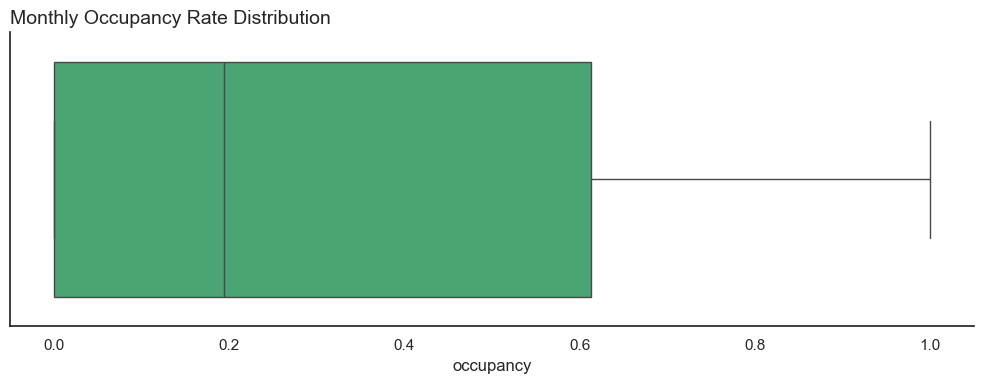

In [4]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=past_rates, x='occupancy', color='mediumseagreen', fliersize=1)
plt.title('Monthly Occupancy Rate Distribution', fontsize=14, loc='left')
sns.despine()
plt.show()

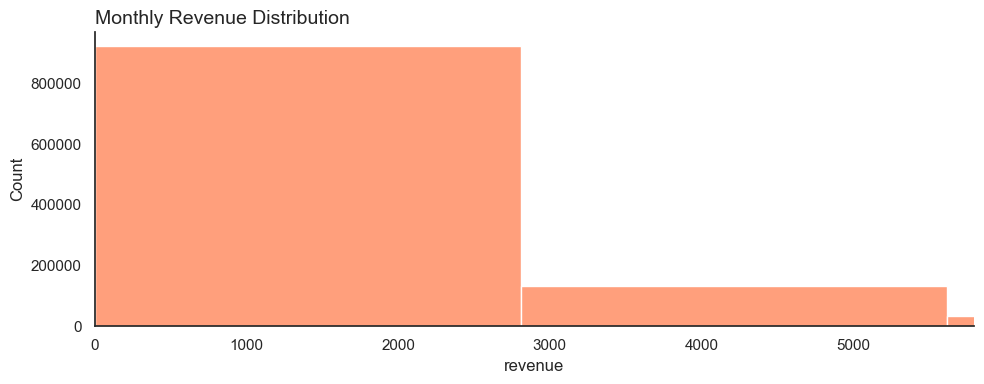

In [5]:
plt.figure(figsize=(10, 4))
sns.histplot(past_rates['revenue'], bins=40, color='coral', edgecolor='white')
plt.title('Monthly Revenue Distribution', fontsize=14, loc='left')
plt.xlim(0, past_rates['revenue'].quantile(0.95))
sns.despine()
plt.show()

## 2. Bivariate Analysis

/var/folders/jq/th0vcfvs2js6n7b3t8b1cn_40000gn/T/ipykernel_93921/1377836963.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_rev.values, y=type_rev.index, palette='Blues_r')


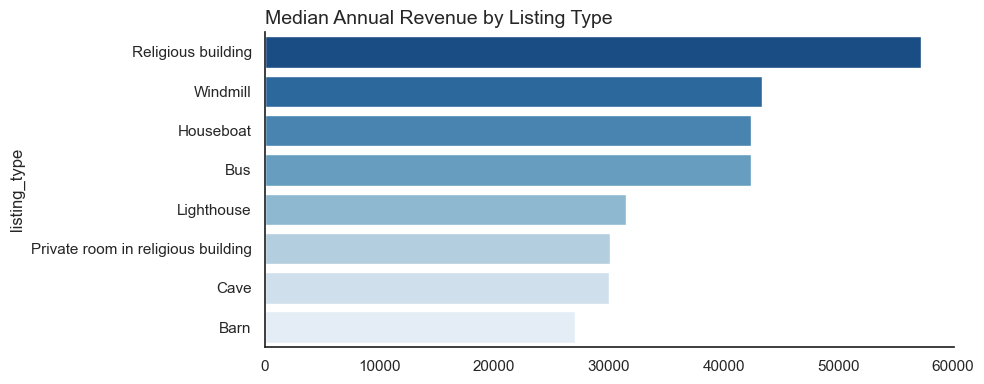

In [6]:
plt.figure(figsize=(10, 4))
type_rev = listings.groupby('listing_type')['ttm_revenue'].median().sort_values(ascending=False).head(8)
sns.barplot(x=type_rev.values, y=type_rev.index, palette='Blues_r')
plt.title('Median Annual Revenue by Listing Type', fontsize=14, loc='left')
sns.despine()
plt.show()

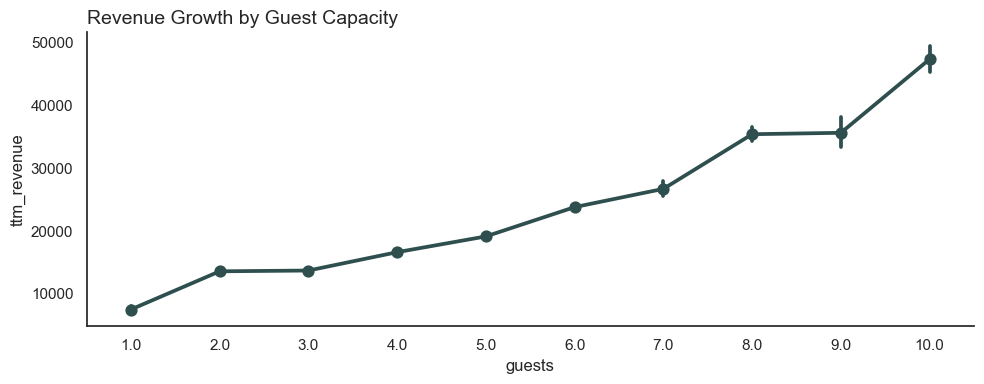

In [7]:
plt.figure(figsize=(10, 4))
sns.pointplot(data=listings[listings['guests'] <= 10], x='guests', y='ttm_revenue', linestyles='-', markers='o', color='darkslategray')
plt.title('Revenue Growth by Guest Capacity', fontsize=14, loc='left')
sns.despine()
plt.show()

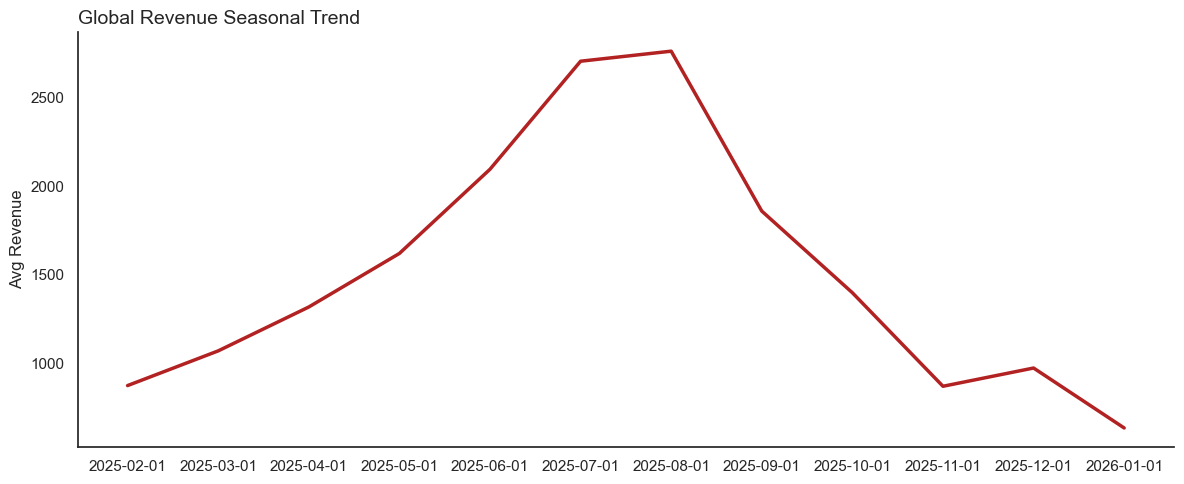

In [8]:
plt.figure(figsize=(12, 5))
monthly_agg = past_rates.groupby('date')['revenue'].mean()
plt.plot(monthly_agg.index, monthly_agg.values, color='firebrick', lw=2.5)
plt.title('Global Revenue Seasonal Trend', fontsize=14, loc='left')
plt.ylabel('Avg Revenue')
sns.despine()
plt.show()

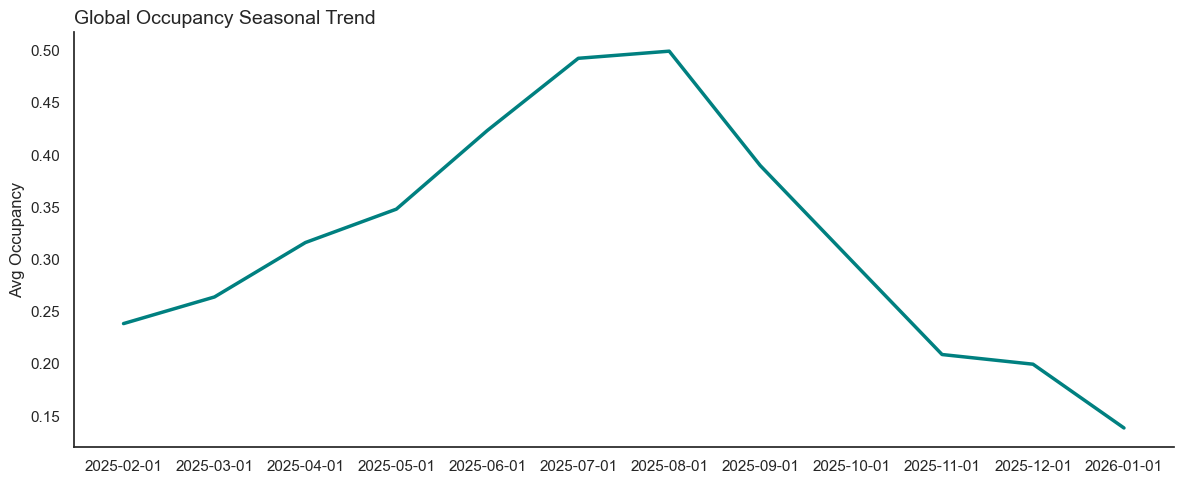

In [9]:
plt.figure(figsize=(12, 5))
monthly_occ = past_rates.groupby('date')['occupancy'].mean()
plt.plot(monthly_occ.index, monthly_occ.values, color='teal', lw=2.5)
plt.title('Global Occupancy Seasonal Trend', fontsize=14, loc='left')
plt.ylabel('Avg Occupancy')
sns.despine()
plt.show()

## 3. Multivariate Analysis

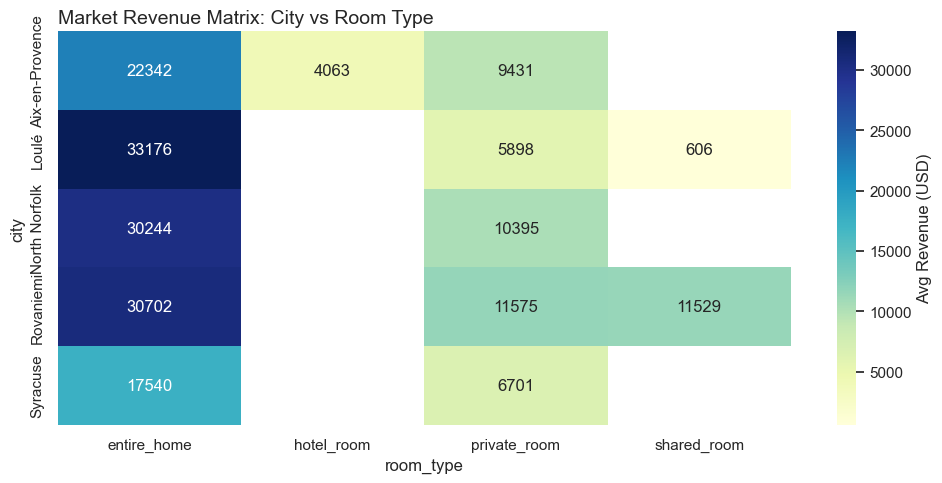

In [10]:
top_cities_full = listings['city'].value_counts().head(5).index
pivot_df = listings[listings['city'].isin(top_cities_full)].pivot_table(values='ttm_revenue', index='city', columns='room_type', aggfunc='mean')
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Avg Revenue (USD)'})
plt.title('Market Revenue Matrix: City vs Room Type', fontsize=14, loc='left')
plt.show()

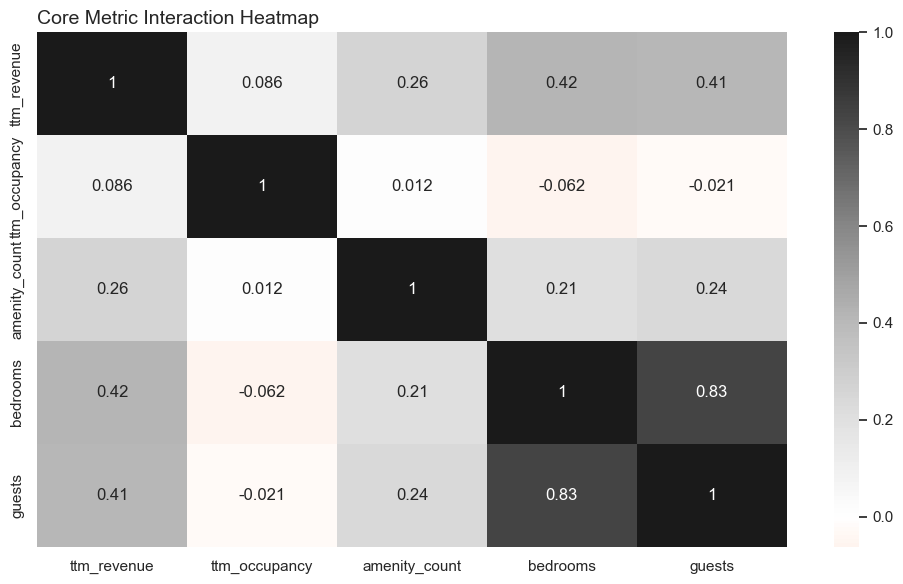

In [11]:
plt.figure(figsize=(10, 6))
corr = listings[['ttm_revenue', 'ttm_occupancy', 'amenity_count', 'bedrooms', 'guests']].corr()
sns.heatmap(corr, annot=True, cmap='RdGy', center=0)
plt.title('Core Metric Interaction Heatmap', fontsize=14, loc='left')
plt.show()

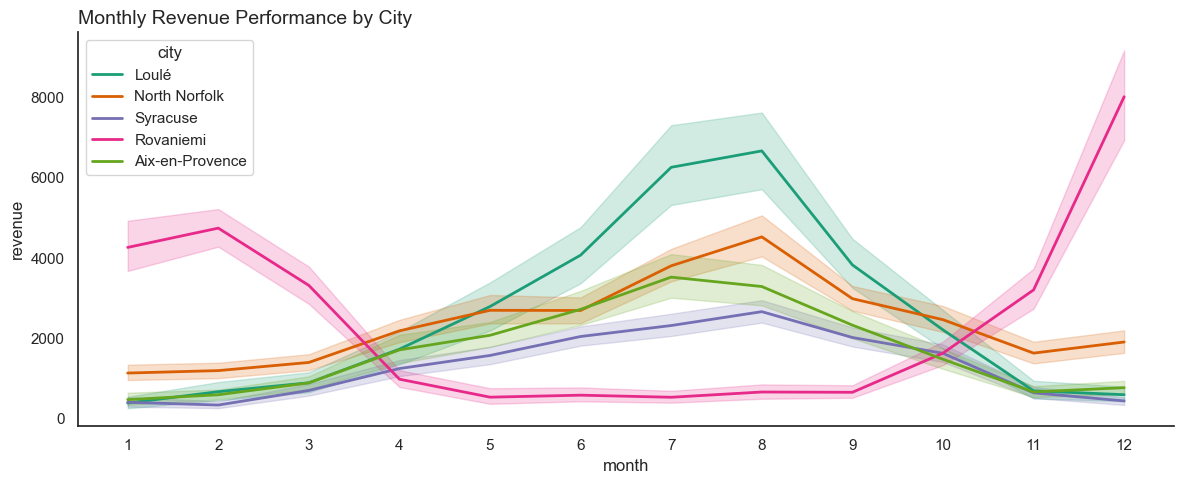

In [12]:
plt.figure(figsize=(12, 5))
city_seasonal = past_rates[past_rates['city'].isin(top_cities_full)].copy()
city_seasonal['date'] = pd.to_datetime(city_seasonal['date'])
city_seasonal['month'] = city_seasonal['date'].dt.month
sns.lineplot(data=city_seasonal, x='month', y='revenue', hue='city', palette='Dark2', lw=2)
plt.title('Monthly Revenue Performance by City', fontsize=14, loc='left')
plt.xticks(range(1,13))
sns.despine()
plt.show()

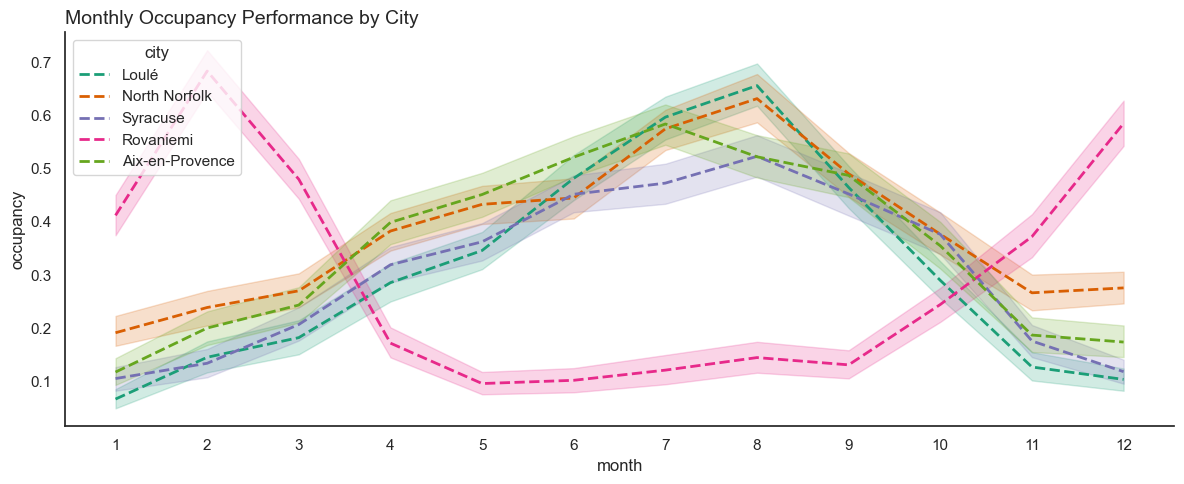

In [13]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=city_seasonal, x='month', y='occupancy', hue='city', palette='Dark2', lw=2, linestyle='--')
plt.title('Monthly Occupancy Performance by City', fontsize=14, loc='left')
plt.xticks(range(1,13))
sns.despine()
plt.show()